# SVM

## Importar Dados

In [1]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## SVM - Default

In [2]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=14)
svm.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.8108
Precisão: 0.7996
Recall: 0.7517
F1-Score: 0.7673
MCC: 0.5492
AUC: 0.8611
--------------------------------------------------


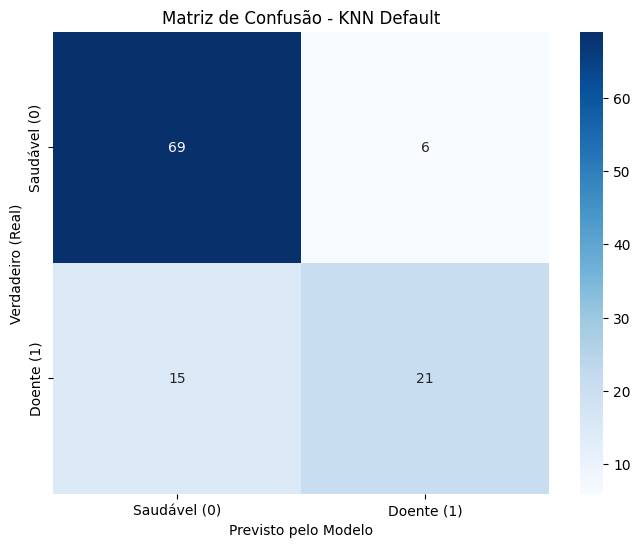

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = svm.predict(X_test)
y_prob_def = svm.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## SVM - Melhorado

In [4]:
import optuna
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Seleciona o kernel primeiro para poder condicionar outros parâmetros
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])

    params = {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel': kernel,
        'tol': trial.suggest_float('tol', 1e-5, 1e-1, log=True),
        'shrinking': trial.suggest_categorical('shrinking', [True, False]),
        'random_state': 14
    }

    # Hiperparâmetros condicionais
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)
        params['coef0'] = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        params['coef0'] = trial.suggest_float('coef0', 0.0, 1.0)

    clf = SVC(**params, probability=True)

    # Cross-validation
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5, n_jobs=-1).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_svm = SVC(**study.best_params, probability=True, random_state=14)
best_svm.fit(X_train, y_train.values.ravel())

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-16 11:32:35,610] A new study created in memory with name: no-name-91fce700-1e9a-472d-afbe-1397af3dc045
Best trial: 0. Best value: 0.814253:   1%|          | 1/100 [00:04<08:09,  4.94s/it]

[I 2026-08-16 11:32:40,549] Trial 0 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 21.830859999515557, 'gamma': 'auto', 'tol': 0.002234480100476094, 'shrinking': False}. Best is trial 0 with value: 0.8142533936651585.


Best trial: 0. Best value: 0.814253:   2%|▏         | 2/100 [00:08<07:11,  4.40s/it]

[I 2026-08-16 11:32:44,567] Trial 1 finished with value: 0.6705128205128205 and parameters: {'kernel': 'poly', 'C': 0.1798538985925676, 'gamma': 'auto', 'tol': 0.0003483437623591489, 'shrinking': False, 'degree': 2, 'coef0': 0.43235150973697434}. Best is trial 0 with value: 0.8142533936651585.


Best trial: 0. Best value: 0.814253:   4%|▍         | 4/100 [00:11<03:38,  2.28s/it]

[I 2026-08-16 11:32:47,342] Trial 2 finished with value: 0.7906485671191554 and parameters: {'kernel': 'poly', 'C': 0.10050628579410245, 'gamma': 'scale', 'tol': 7.094793873283743e-05, 'shrinking': True, 'degree': 4, 'coef0': 0.2983463705292352}. Best is trial 0 with value: 0.8142533936651585.
[I 2026-08-16 11:32:47,508] Trial 3 finished with value: 0.7442684766214178 and parameters: {'kernel': 'poly', 'C': 5.794294951267461, 'gamma': 'scale', 'tol': 0.00010543557941863644, 'shrinking': False, 'degree': 3, 'coef0': 0.7276874955612568}. Best is trial 0 with value: 0.8142533936651585.


Best trial: 5. Best value: 0.8181:   6%|▌         | 6/100 [00:12<01:43,  1.10s/it]  

[I 2026-08-16 11:32:47,564] Trial 4 finished with value: 0.8024886877828052 and parameters: {'kernel': 'rbf', 'C': 0.3774575001540249, 'gamma': 'scale', 'tol': 2.2905875424264548e-05, 'shrinking': True}. Best is trial 0 with value: 0.8142533936651585.
[I 2026-08-16 11:32:47,622] Trial 5 finished with value: 0.8180995475113122 and parameters: {'kernel': 'rbf', 'C': 23.692362775217543, 'gamma': 'auto', 'tol': 3.7845884596887075e-05, 'shrinking': True}. Best is trial 5 with value: 0.8180995475113122.
[I 2026-08-16 11:32:47,682] Trial 6 finished with value: 0.77526395173454 and parameters: {'kernel': 'poly', 'C': 0.3648174101548431, 'gamma': 'scale', 'tol': 0.0102490025429021, 'shrinking': True, 'degree': 4, 'coef0': 0.22679630616681734}. Best is trial 5 with value: 0.8180995475113122.


Best trial: 5. Best value: 0.8181:  10%|█         | 10/100 [00:12<00:38,  2.33it/s]

[I 2026-08-16 11:32:47,772] Trial 7 finished with value: 0.7828808446455505 and parameters: {'kernel': 'poly', 'C': 0.7903618627140276, 'gamma': 'scale', 'tol': 1.389107526370083e-05, 'shrinking': True, 'degree': 3, 'coef0': 0.20581677204231597}. Best is trial 5 with value: 0.8180995475113122.
[I 2026-08-16 11:32:47,837] Trial 8 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 1.3776774062769828, 'gamma': 'auto', 'tol': 0.0006376927530359832, 'shrinking': True, 'coef0': 0.9518817701259821}. Best is trial 5 with value: 0.8180995475113122.
[I 2026-08-16 11:32:47,886] Trial 9 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.24630178556588642, 'gamma': 'auto', 'tol': 8.190430186685228e-05, 'shrinking': True}. Best is trial 5 with value: 0.8180995475113122.
[I 2026-08-16 11:32:47,925] Trial 10 finished with value: 0.8026395173453998 and parameters: {'kernel': 'sigmoid', 'C': 88.99570614093201, 'gamma': 'auto', 'tol': 0.089130

Best trial: 13. Best value: 0.82994:  14%|█▍        | 14/100 [00:12<00:21,  3.91it/s] 

[I 2026-08-16 11:32:47,970] Trial 11 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 21.084721744417973, 'gamma': 'auto', 'tol': 0.004766926096636303, 'shrinking': False}. Best is trial 5 with value: 0.8180995475113122.
[I 2026-08-16 11:32:48,011] Trial 12 finished with value: 0.8220211161387632 and parameters: {'kernel': 'rbf', 'C': 16.006331854166895, 'gamma': 'auto', 'tol': 0.002590258563921023, 'shrinking': False}. Best is trial 12 with value: 0.8220211161387632.
[I 2026-08-16 11:32:48,066] Trial 13 finished with value: 0.8299396681749623 and parameters: {'kernel': 'rbf', 'C': 9.21431261805773, 'gamma': 'auto', 'tol': 0.020714113529303038, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,110] Trial 14 finished with value: 0.806711915535445 and parameters: {'kernel': 'rbf', 'C': 5.2515742580983735, 'gamma': 'auto', 'tol': 0.029914052002200864, 'shrinking': False}. Best is trial 13 with value: 0.82993966817496

Best trial: 13. Best value: 0.82994:  19%|█▉        | 19/100 [00:12<00:10,  7.89it/s]

[I 2026-08-16 11:32:48,151] Trial 15 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.680728416167591, 'gamma': 'auto', 'tol': 0.013483452136929813, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,193] Trial 16 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 2.524044534939139, 'gamma': 'auto', 'tol': 0.021749307547197273, 'shrinking': False, 'coef0': 0.6857511094873449}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,244] Trial 17 finished with value: 0.8064856711915536 and parameters: {'kernel': 'rbf', 'C': 54.817336528169974, 'gamma': 'auto', 'tol': 0.05882345445069024, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,285] Trial 18 finished with value: 0.8144796380090498 and parameters: {'kernel': 'rbf', 'C': 7.833527101663974, 'gamma': 'auto', 'tol': 0.011350353737153391, 'shrinking': False}. Best is tria

Best trial: 13. Best value: 0.82994:  23%|██▎       | 23/100 [00:12<00:07,  9.91it/s]

[I 2026-08-16 11:32:48,368] Trial 20 finished with value: 0.7013574660633484 and parameters: {'kernel': 'sigmoid', 'C': 9.680012254166245, 'gamma': 'auto', 'tol': 0.030845253387422195, 'shrinking': False, 'coef0': 0.9624454654035013}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,430] Trial 21 finished with value: 0.8181749622926094 and parameters: {'kernel': 'rbf', 'C': 13.595831300163441, 'gamma': 'auto', 'tol': 0.0016221605324780934, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,480] Trial 22 finished with value: 0.8064856711915536 and parameters: {'kernel': 'rbf', 'C': 45.09046521253487, 'gamma': 'auto', 'tol': 0.003347573270761443, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,524] Trial 23 finished with value: 0.8105580693815988 and parameters: {'kernel': 'rbf', 'C': 3.9651451903211745, 'gamma': 'auto', 'tol': 0.010072939455163249, 'shrinking': False}. Best is t

Best trial: 13. Best value: 0.82994:  28%|██▊       | 28/100 [00:13<00:05, 13.83it/s]

[I 2026-08-16 11:32:48,568] Trial 24 finished with value: 0.8181749622926094 and parameters: {'kernel': 'rbf', 'C': 14.047639726797183, 'gamma': 'auto', 'tol': 0.0008812405220778642, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,628] Trial 25 finished with value: 0.8064856711915536 and parameters: {'kernel': 'rbf', 'C': 33.537855536120915, 'gamma': 'auto', 'tol': 0.00031640527338272387, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,674] Trial 26 finished with value: 0.7909502262443439 and parameters: {'kernel': 'rbf', 'C': 10.84255002787991, 'gamma': 'scale', 'tol': 0.013530609863231203, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,720] Trial 27 finished with value: 0.7014328808446455 and parameters: {'kernel': 'rbf', 'C': 1.805803089561952, 'gamma': 'auto', 'tol': 0.04439908957411888, 'shrinking': False}. Best is trial 13 with value: 0.829939668

Best trial: 13. Best value: 0.82994:  32%|███▏      | 32/100 [00:13<00:04, 15.68it/s]

[I 2026-08-16 11:32:48,764] Trial 28 finished with value: 0.8106334841628959 and parameters: {'kernel': 'rbf', 'C': 6.344382961946671, 'gamma': 'auto', 'tol': 0.005691130374181748, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,808] Trial 29 finished with value: 0.806711915535445 and parameters: {'kernel': 'sigmoid', 'C': 19.594196912612844, 'gamma': 'auto', 'tol': 0.017791884080425032, 'shrinking': False, 'coef0': 0.6468584173082526}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,854] Trial 30 finished with value: 0.8105580693815988 and parameters: {'kernel': 'rbf', 'C': 3.976679190329489, 'gamma': 'auto', 'tol': 0.0017893042799785436, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:48,897] Trial 31 finished with value: 0.8181749622926094 and parameters: {'kernel': 'rbf', 'C': 13.846791693016478, 'gamma': 'auto', 'tol': 0.001758456694441942, 'shrinking': False}. Best is tr

Best trial: 13. Best value: 0.82994:  37%|███▋      | 37/100 [00:13<00:03, 18.96it/s]

[I 2026-08-16 11:32:48,973] Trial 33 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 21.928727689465532, 'gamma': 'auto', 'tol': 0.0035058392975232744, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,018] Trial 34 finished with value: 0.8143288084464555 and parameters: {'kernel': 'poly', 'C': 30.78405702251337, 'gamma': 'auto', 'tol': 0.0005105678286615834, 'shrinking': False, 'degree': 2, 'coef0': 0.47326849091961803}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,066] Trial 35 finished with value: 0.7598039215686275 and parameters: {'kernel': 'rbf', 'C': 67.71902831285892, 'gamma': 'scale', 'tol': 0.007693690997946359, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,107] Trial 36 finished with value: 0.8220965309200604 and parameters: {'kernel': 'rbf', 'C': 9.655724635445194, 'gamma': 'auto', 'tol': 0.0030814048972276627, 'shrinking': Fals

Best trial: 13. Best value: 0.82994:  40%|████      | 40/100 [00:13<00:03, 18.63it/s]

[I 2026-08-16 11:32:49,160] Trial 37 finished with value: 0.7865761689291102 and parameters: {'kernel': 'poly', 'C': 8.538507513992919, 'gamma': 'scale', 'tol': 0.00023597127913769678, 'shrinking': False, 'degree': 2, 'coef0': 0.05463975062668308}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,200] Trial 38 finished with value: 0.8067873303167421 and parameters: {'kernel': 'rbf', 'C': 5.716488815467795, 'gamma': 'auto', 'tol': 0.0011734245168868826, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,275] Trial 39 finished with value: 0.7638763197586727 and parameters: {'kernel': 'poly', 'C': 28.893462149119873, 'gamma': 'scale', 'tol': 0.021743364707087504, 'shrinking': True, 'degree': 4, 'coef0': 0.8667246967022735}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,305] Trial 40 finished with value: 0.8144042232277527 and parameters: {'kernel': 'rbf', 'C': 4.688737444296776, 'gamma': 'auto', 'tol

Best trial: 13. Best value: 0.82994:  45%|████▌     | 45/100 [00:13<00:02, 20.90it/s]

[I 2026-08-16 11:32:49,345] Trial 41 finished with value: 0.8220211161387632 and parameters: {'kernel': 'rbf', 'C': 16.20451677664407, 'gamma': 'auto', 'tol': 0.002982538417522961, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,377] Trial 42 finished with value: 0.8220965309200604 and parameters: {'kernel': 'rbf', 'C': 11.091068527772157, 'gamma': 'auto', 'tol': 0.0027425462735193216, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,435] Trial 43 finished with value: 0.8144796380090498 and parameters: {'kernel': 'rbf', 'C': 7.899211694274245, 'gamma': 'auto', 'tol': 0.0010080801056824877, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,477] Trial 44 finished with value: 0.8220965309200604 and parameters: {'kernel': 'rbf', 'C': 11.595789017235962, 'gamma': 'auto', 'tol': 0.004582864633434692, 'shrinking': False}. Best is trial 13 with value: 0.8299396681

Best trial: 13. Best value: 0.82994:  49%|████▉     | 49/100 [00:14<00:02, 21.15it/s]

[I 2026-08-16 11:32:49,566] Trial 46 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 0.84253003826965, 'gamma': 'auto', 'tol': 0.016754194793767815, 'shrinking': False, 'coef0': 0.5672460274348275}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,618] Trial 47 finished with value: 0.8141779788838612 and parameters: {'kernel': 'rbf', 'C': 3.3831657385358302, 'gamma': 'scale', 'tol': 0.09328431628158995, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,661] Trial 48 finished with value: 0.8105580693815988 and parameters: {'kernel': 'poly', 'C': 7.22225790354248, 'gamma': 'auto', 'tol': 0.037977421546196995, 'shrinking': True, 'degree': 3, 'coef0': 0.3746154326634519}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,702] Trial 49 finished with value: 0.8064856711915536 and parameters: {'kernel': 'rbf', 'C': 40.16297683530056, 'gamma': 'auto', 'tol': 0.007154417122

Best trial: 13. Best value: 0.82994:  55%|█████▌    | 55/100 [00:14<00:02, 22.39it/s]

[I 2026-08-16 11:32:49,744] Trial 50 finished with value: 0.8220965309200604 and parameters: {'kernel': 'rbf', 'C': 11.185800657886919, 'gamma': 'auto', 'tol': 0.004049284416288083, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,785] Trial 51 finished with value: 0.8220965309200604 and parameters: {'kernel': 'rbf', 'C': 11.15815751257452, 'gamma': 'auto', 'tol': 0.004111083632795545, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,835] Trial 52 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 23.20563390690354, 'gamma': 'auto', 'tol': 0.0020575778511109644, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,878] Trial 53 finished with value: 0.7716440422322776 and parameters: {'kernel': 'rbf', 'C': 2.7184314039796624, 'gamma': 'auto', 'tol': 0.01303172385547101, 'shrinking': False}. Best is trial 13 with value: 0.829939668174

Best trial: 13. Best value: 0.82994:  58%|█████▊    | 58/100 [00:14<00:01, 21.95it/s]

[I 2026-08-16 11:32:49,956] Trial 55 finished with value: 0.7833333333333333 and parameters: {'kernel': 'sigmoid', 'C': 12.127411755790506, 'gamma': 'auto', 'tol': 0.0063302867319289455, 'shrinking': False, 'coef0': 0.7744284988471293}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:49,998] Trial 56 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.1296336347026126, 'gamma': 'auto', 'tol': 0.009751746657255853, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,052] Trial 57 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.19772099619204, 'gamma': 'auto', 'tol': 0.0025205797508673915, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,097] Trial 58 finished with value: 0.8144042232277527 and parameters: {'kernel': 'rbf', 'C': 4.244186528779683, 'gamma': 'auto', 'tol': 0.0005733136419960857, 'shrinking': False}. Best is 

Best trial: 13. Best value: 0.82994:  62%|██████▏   | 62/100 [00:14<00:01, 22.17it/s]

[I 2026-08-16 11:32:50,139] Trial 59 finished with value: 0.8299396681749623 and parameters: {'kernel': 'rbf', 'C': 9.077110368844853, 'gamma': 'auto', 'tol': 0.058681185002254, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,184] Trial 60 finished with value: 0.8181749622926094 and parameters: {'kernel': 'rbf', 'C': 1.848087976299908, 'gamma': 'scale', 'tol': 0.0519361126082383, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,235] Trial 61 finished with value: 0.8183257918552037 and parameters: {'kernel': 'rbf', 'C': 8.56271557448247, 'gamma': 'auto', 'tol': 0.07085299790764689, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,280] Trial 62 finished with value: 0.8106334841628959 and parameters: {'kernel': 'rbf', 'C': 6.479997253930258, 'gamma': 'auto', 'tol': 0.028669038451234374, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.


Best trial: 13. Best value: 0.82994:  67%|██████▋   | 67/100 [00:14<00:01, 20.31it/s]

[I 2026-08-16 11:32:50,325] Trial 63 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 18.04513007268156, 'gamma': 'auto', 'tol': 0.0023866694629443214, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,382] Trial 64 finished with value: 0.8298642533936652 and parameters: {'kernel': 'rbf', 'C': 9.304157037616523, 'gamma': 'auto', 'tol': 0.023471805469947916, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,441] Trial 65 finished with value: 0.806711915535445 and parameters: {'kernel': 'rbf', 'C': 5.289388014221653, 'gamma': 'auto', 'tol': 0.024533454269860314, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,497] Trial 66 finished with value: 0.7831825037707391 and parameters: {'kernel': 'sigmoid', 'C': 9.633859500289393, 'gamma': 'auto', 'tol': 0.07088781570915303, 'shrinking': True, 'coef0': 0.5686401283724789}. Best is trial 13 

Best trial: 13. Best value: 0.82994:  70%|███████   | 70/100 [00:15<00:01, 20.30it/s]

[I 2026-08-16 11:32:50,550] Trial 67 finished with value: 0.794947209653092 and parameters: {'kernel': 'rbf', 'C': 3.3935066115223056, 'gamma': 'auto', 'tol': 0.0368549282323062, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,596] Trial 68 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 26.240870822428263, 'gamma': 'auto', 'tol': 0.020047463016217133, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,649] Trial 69 finished with value: 0.806711915535445 and parameters: {'kernel': 'poly', 'C': 13.926488565238499, 'gamma': 'auto', 'tol': 0.014489170749817792, 'shrinking': True, 'degree': 2, 'coef0': 0.1403002541922551}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,692] Trial 70 finished with value: 0.8144796380090498 and parameters: {'kernel': 'rbf', 'C': 7.322287995011921, 'gamma': 'auto', 'tol': 0.05001575244569946, 'shrinking': True}. Best is 

Best trial: 13. Best value: 0.82994:  74%|███████▍  | 74/100 [00:15<00:01, 20.33it/s]

[I 2026-08-16 11:32:50,734] Trial 71 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 8.88733515981789, 'gamma': 'auto', 'tol': 0.0007555461699179354, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,791] Trial 72 finished with value: 0.8144042232277527 and parameters: {'kernel': 'rbf', 'C': 4.696066503526259, 'gamma': 'auto', 'tol': 0.0007607487357816616, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,841] Trial 73 finished with value: 0.8142533936651585 and parameters: {'kernel': 'rbf', 'C': 19.604294546867283, 'gamma': 'auto', 'tol': 0.00018481060689940702, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,884] Trial 74 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.066906845397268, 'gamma': 'auto', 'tol': 2.638240222292401e-05, 'shrinking': False}. Best is trial 13 with value: 0.829939668

Best trial: 13. Best value: 0.82994:  79%|███████▉  | 79/100 [00:15<00:01, 19.71it/s]

[I 2026-08-16 11:32:50,929] Trial 75 finished with value: 0.8183257918552037 and parameters: {'kernel': 'rbf', 'C': 8.170325372247328, 'gamma': 'auto', 'tol': 3.935039626508692e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:50,972] Trial 76 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 8.962484514239636, 'gamma': 'auto', 'tol': 1.1362926163024928e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,044] Trial 77 finished with value: 0.8220211161387632 and parameters: {'kernel': 'rbf', 'C': 16.250631512557067, 'gamma': 'auto', 'tol': 1.276860380621788e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,103] Trial 78 finished with value: 0.8024886877828055 and parameters: {'kernel': 'rbf', 'C': 6.616095593997804, 'gamma': 'scale', 'tol': 1.732491112309892e-05, 'shrinking': True}. Best is trial 13 with value: 0.82993966

Best trial: 13. Best value: 0.82994:  82%|████████▏ | 82/100 [00:15<00:00, 20.62it/s]

[I 2026-08-16 11:32:51,148] Trial 79 finished with value: 0.806711915535445 and parameters: {'kernel': 'rbf', 'C': 5.278684112109704, 'gamma': 'auto', 'tol': 2.75743102661833e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,202] Trial 80 finished with value: 0.7794117647058824 and parameters: {'kernel': 'sigmoid', 'C': 13.452531453540145, 'gamma': 'auto', 'tol': 8.734012641338685e-05, 'shrinking': False, 'coef0': 0.8562105473642774}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,236] Trial 81 finished with value: 0.8182503770739066 and parameters: {'kernel': 'rbf', 'C': 13.346948774607936, 'gamma': 'auto', 'tol': 1.0552839689819467e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,279] Trial 82 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.141740355031898, 'gamma': 'auto', 'tol': 4.9439794802086856e-05, 'shrinking': False}. Best i

Best trial: 13. Best value: 0.82994:  88%|████████▊ | 88/100 [00:15<00:00, 21.49it/s]

[I 2026-08-16 11:32:51,324] Trial 83 finished with value: 0.8221719457013575 and parameters: {'kernel': 'rbf', 'C': 8.730726166356364, 'gamma': 'auto', 'tol': 5.525526425898801e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,366] Trial 84 finished with value: 0.8106334841628959 and parameters: {'kernel': 'rbf', 'C': 6.818786140493198, 'gamma': 'auto', 'tol': 2.5143005442910672e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,414] Trial 85 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.534823073856712, 'gamma': 'auto', 'tol': 1.8780305280907626e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,458] Trial 86 finished with value: 0.7131975867269985 and parameters: {'kernel': 'poly', 'C': 4.31028110120303, 'gamma': 'auto', 'tol': 3.5809253216463845e-05, 'shrinking': False, 'degree': 3, 'coef0': 0.317520329650346

Best trial: 13. Best value: 0.82994:  91%|█████████ | 91/100 [00:16<00:00, 21.03it/s]

[I 2026-08-16 11:32:51,546] Trial 88 finished with value: 0.806711915535445 and parameters: {'kernel': 'rbf', 'C': 5.468815099340985, 'gamma': 'auto', 'tol': 0.0004359354707763426, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,604] Trial 89 finished with value: 0.7947963800904977 and parameters: {'kernel': 'rbf', 'C': 8.01573997614822, 'gamma': 'scale', 'tol': 0.0001155042546917827, 'shrinking': True}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,655] Trial 90 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.39905220053357915, 'gamma': 'auto', 'tol': 1.7829895604356757e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,686] Trial 91 finished with value: 0.8260180995475114 and parameters: {'kernel': 'rbf', 'C': 9.091289742524364, 'gamma': 'auto', 'tol': 2.1155125118425186e-05, 'shrinking': False}. Best is trial 13 with value: 0.82993966

Best trial: 13. Best value: 0.82994:  95%|█████████▌| 95/100 [00:16<00:00, 21.80it/s]

[I 2026-08-16 11:32:51,728] Trial 92 finished with value: 0.8181749622926094 and parameters: {'kernel': 'rbf', 'C': 10.352738122415193, 'gamma': 'auto', 'tol': 3.132271332776007e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,774] Trial 93 finished with value: 0.8144796380090498 and parameters: {'kernel': 'rbf', 'C': 7.506054737962289, 'gamma': 'auto', 'tol': 1.4266330409260363e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,837] Trial 94 finished with value: 0.8182503770739066 and parameters: {'kernel': 'rbf', 'C': 12.486362429891159, 'gamma': 'auto', 'tol': 1.046613444797134e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,882] Trial 95 finished with value: 0.8221719457013575 and parameters: {'kernel': 'rbf', 'C': 9.318797321080014, 'gamma': 'auto', 'tol': 4.436463379669014e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396

Best trial: 13. Best value: 0.82994: 100%|██████████| 100/100 [00:16<00:00,  6.07it/s]

[I 2026-08-16 11:32:51,926] Trial 96 finished with value: 0.8106334841628959 and parameters: {'kernel': 'rbf', 'C': 5.966661500943971, 'gamma': 'auto', 'tol': 2.0984650510877936e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:51,975] Trial 97 finished with value: 0.8220211161387632 and parameters: {'kernel': 'rbf', 'C': 15.169699308740952, 'gamma': 'auto', 'tol': 0.03399347340670879, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:52,024] Trial 98 finished with value: 0.806711915535445 and parameters: {'kernel': 'rbf', 'C': 3.710948423502617, 'gamma': 'auto', 'tol': 1.5933651509136704e-05, 'shrinking': False}. Best is trial 13 with value: 0.8299396681749623.
[I 2026-08-16 11:32:52,073] Trial 99 finished with value: 0.8183257918552037 and parameters: {'kernel': 'poly', 'C': 11.679629948600134, 'gamma': 'auto', 'tol': 0.00012173966672976579, 'shrinking': True, 'degree': 4, 'coef0': 0.5690182578429953

,C,9.21431261805773
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,False
,probability,True
,tol,0.020714113529303038
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (SVM) ===
      feature  importance_mean  importance_std
 neutrophilsP           0.0492          0.0159
    platelets           0.0462          0.0174
 lymphocytesP           0.0429          0.0127
   leukocytes           0.0408          0.0236
         mchc           0.0393          0.0126
  lymphocytes           0.0390          0.0231
   basophilsP           0.0354          0.0152
  eosinophils           0.0321          0.0133
redbloodcells           0.0279          0.0107
   monocytesP           0.0270          0.0116
          mpv           0.0261          0.0158
   hemoglobin           0.0258          0.0101
 eosinophilsP           0.0225          0.0101
          mcv           0.0099          0.0043
  neutrophils           0.0081          0.0082
          mch           0.0081          0.0075
    basophils           0.0072          0.0082
  hematocritP           0.0030          0.0054
    monocytes           0.0027          0.0058
         rdwP        

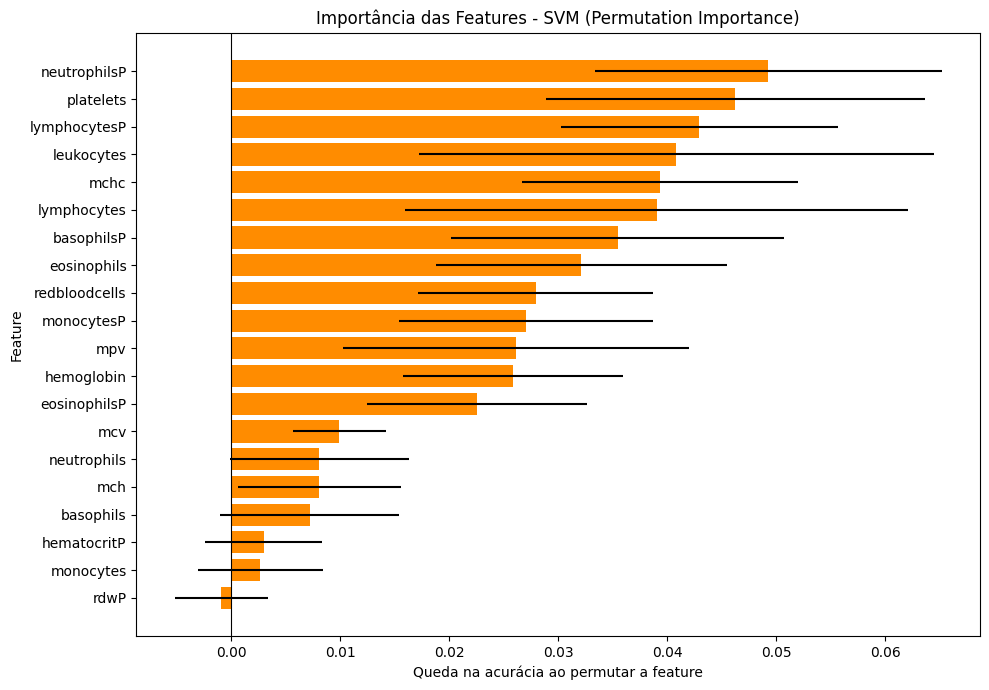

In [6]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Importância por permutação: mede a queda na acurácia ao embaralhar cada feature
perm = permutation_importance(
    best_svm,
    X_test,
    y_test.values.ravel(),
    n_repeats=30,
    random_state=42,
    scoring='accuracy'
)

feature_names = X_train.columns.tolist()
importancia = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (SVM) ===')
print(importancia.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_names))))
plt.barh(
    importancia['feature'],
    importancia['importance_mean'],
    xerr=importancia['importance_std'],
    align='center',
    color='darkorange'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Importância das Features - SVM (Permutation Importance)')
plt.xlabel('Queda na acurácia ao permutar a feature')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.8288
Precisão: 0.8173
Recall:   0.7794
F1-Score: 0.7933
MCC:      0.5955
AUC:      0.8293
--------------------------------------------------


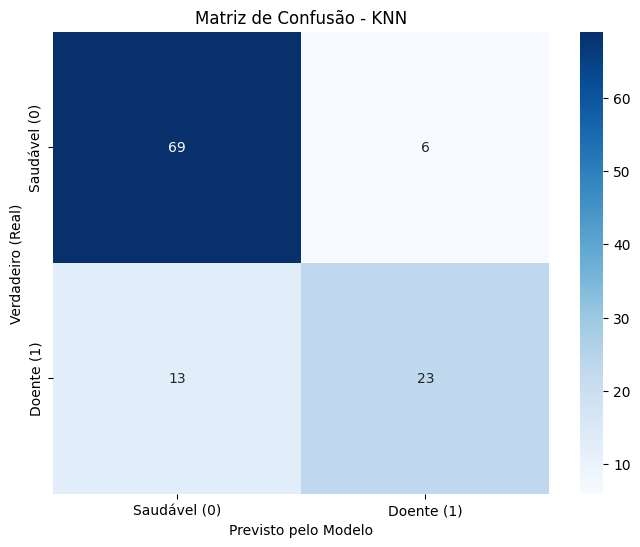

In [7]:
# Fazendo as Previsões
y_pred_best = best_svm.predict(X_test)
y_prob_best = best_svm.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [8]:
import os
import pandas as pd

nome_modelo = 'svm'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo svm salvas com sucesso!
